In [178]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


np.random.seed(42)
import pandas as pd
import numpy as np

np.random.seed(42)

data = {
    "MedInc": np.random.randint(60000, 150000, 20000),
    "HouseAge": np.random.randint(1, 30, 20000),   # از 1 شروع تا خطای تقسیم بر صفر نگیری
    "AveRooms": np.random.randint(1, 6, 20000),
    "AveBedrms": np.random.randint(1, 3, 20000),
    "AveOccup": np.random.randint(0, 10, 20000),
    "Latitude": np.random.randint(10, 50, 20000),
    "Longitude": np.random.randint(10, 50, 20000)
}

df = pd.DataFrame(data)

# محاسبه ستون جدید
df["MedHouseVal"] = np.round(((df["AveRooms"]*2) * df["AveBedrms"] * df["Latitude"] * df["Longitude"]*1500)/df["HouseAge"])

# تبدیل به عدد صحیح
df["MedHouseVal"] = df["MedHouseVal"].astype(int)

print(df.dtypes)
print(df.head())


MedInc         int32
HouseAge       int32
AveRooms       int32
AveBedrms      int32
AveOccup       int32
Latitude       int32
Longitude      int32
MedHouseVal    int64
dtype: object
   MedInc  HouseAge  AveRooms  AveBedrms  AveOccup  Latitude  Longitude  \
0   75795        17         4          1         3        17         45   
1   60860        11         4          2         4        13         30   
2  136820         6         2          1         8        44         20   
3  114886         9         5          1         7        21         21   
4   66265        18         3          1         1        33         35   

   MedHouseVal  
0       540000  
1       850909  
2       880000  
3       735000  
4       577500  


In [179]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   MedInc       20000 non-null  int32
 1   HouseAge     20000 non-null  int32
 2   AveRooms     20000 non-null  int32
 3   AveBedrms    20000 non-null  int32
 4   AveOccup     20000 non-null  int32
 5   Latitude     20000 non-null  int32
 6   Longitude    20000 non-null  int32
 7   MedHouseVal  20000 non-null  int64
dtypes: int32(7), int64(1)
memory usage: 703.3 KB


In [180]:
df.duplicated().sum()



np.int64(0)

In [181]:
df.columns

Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup', 'Latitude',
       'Longitude', 'MedHouseVal'],
      dtype='object')

In [182]:
df.size,df.shape


(160000, (20000, 8))

In [183]:
df.dtypes

MedInc         int32
HouseAge       int32
AveRooms       int32
AveBedrms      int32
AveOccup       int32
Latitude       int32
Longitude      int32
MedHouseVal    int64
dtype: object

In [184]:
df.corr()

,MedInc,HouseAge,AveRooms,AveBedrms,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,0.003981,-0.011442,0.001986,0.004774,-0.005644,-0.006860,-0.009202
HouseAge,0.003981,1.000000,-0.006594,-0.010135,0.008294,-0.001260,-0.003952,-0.443401
AveRooms,-0.011442,-0.006594,1.000000,0.001204,0.001165,0.000609,-0.000407,0.234174
AveBedrms,0.001986,-0.010135,0.001204,1.000000,-0.011324,0.003244,-0.003129,0.154305
AveOccup,0.004774,0.008294,0.001165,-0.011324,1.000000,0.007547,0.004199,-0.014028
Latitude,-0.005644,-0.001260,0.000609,0.003244,0.007547,1.000000,-0.003469,0.195396
Longitude,-0.006860,-0.003952,-0.000407,-0.003129,0.004199,-0.003469,1.000000,0.186904
MedHouseVal,-0.009202,-0.443401,0.234174,0.154305,-0.014028,0.195396,0.186904,1.000000


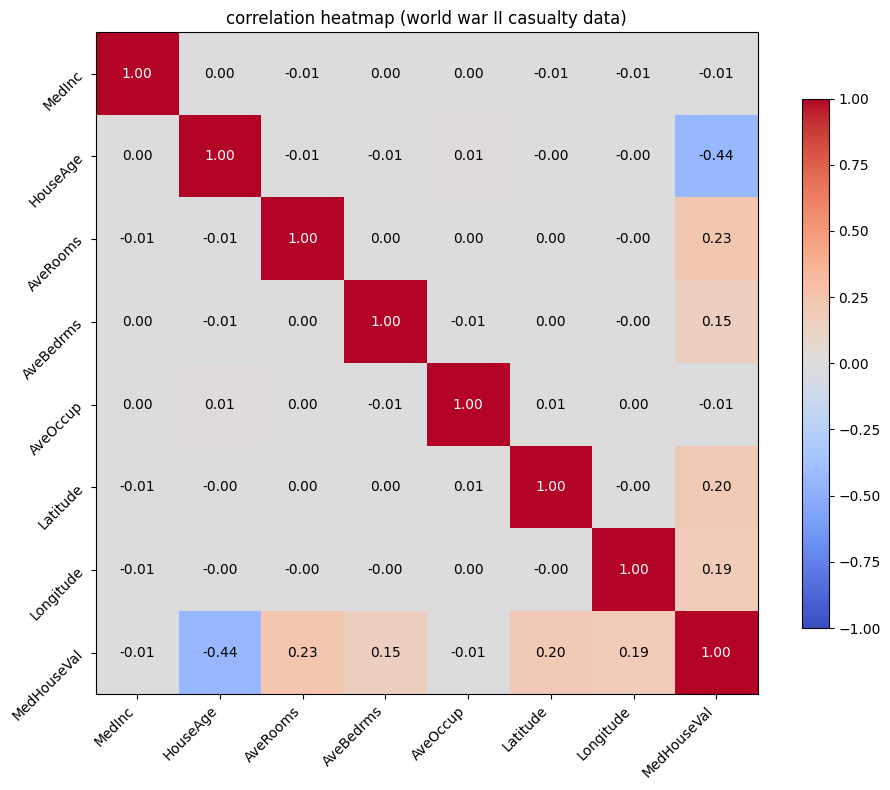

In [185]:
fig,ax=plt.subplots(figsize=(10,8))
cax=ax.imshow(df.corr(),cmap="coolwarm",vmin=-1,vmax=1)
ax.set_xticks(np.arange(len(df.corr().columns)))
ax.set_yticks(np.arange(len(df.corr().columns)))
ax.set_xticklabels(df.corr().columns,rotation=45,ha="right")
ax.set_yticklabels(df.corr().columns,rotation=45,ha="right")
fig.colorbar(cax,shrink=0.8)
for i in range(len(df.corr().columns)):
    for j in range(len(df.corr().columns)):
        text=ax.text(j,i,f"{df.corr().iloc[i,j]:.2f}" if not pd.isna(df.corr().iloc[i,j]) else "",
                                                                     ha="center", va="center",color="black" if abs(df.corr().iloc[i,j])<0.6 else "white")
plt.title("correlation heatmap (world war II casualty data)")
plt.tight_layout()
plt.show()

C:\Users\modernkade\AppData\Local\Temp\ipykernel_13300\2622207039.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ValueCategory", y=col, data=df, palette="Set2")
C:\Users\modernkade\AppData\Local\Temp\ipykernel_13300\2622207039.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ValueCategory", y=col, data=df, palette="Set2")
C:\Users\modernkade\AppData\Local\Temp\ipykernel_13300\2622207039.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="ValueCategory", y=col, data=df, palette="Set2")
C:\Users\modernkade\AppData\Local\Temp\i

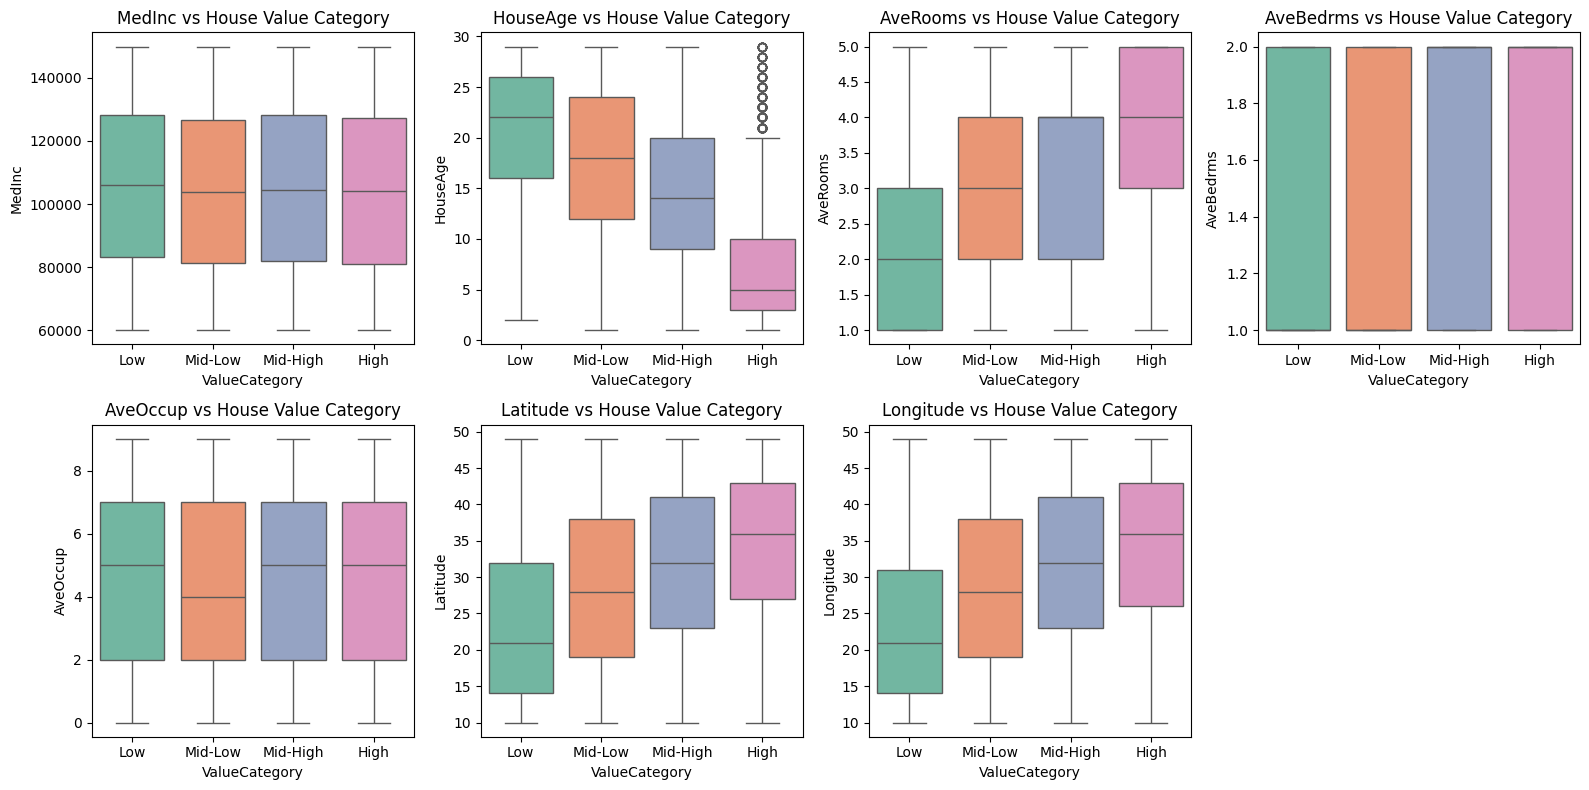

In [186]:


# Create income categories based on quantiles
df["ValueCategory"] = pd.qcut(df["MedHouseVal"], q=4, labels=["Low", "Mid-Low", "Mid-High", "High"])

plt.figure(figsize=(16,8))
for i, col in enumerate(df.columns[:-2], 1):  # skip MedHouseVal & ValueCategory
    plt.subplot(2, 4, i)
    sns.boxplot(x="ValueCategory", y=col, data=df, palette="Set2")
    plt.title(f"{col} vs House Value Category")
    
plt.tight_layout()
plt.show()


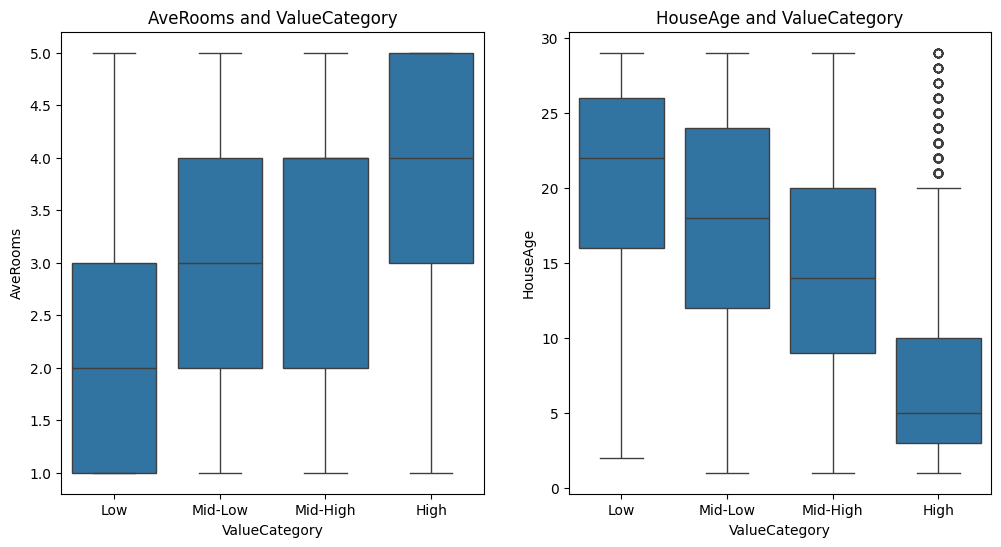

In [187]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.boxplot(data=df,x = "ValueCategory",y="AveRooms")
plt.title("AveRooms and ValueCategory")

plt.subplot(1,2,2)
sns.boxplot(data=df,x = "ValueCategory",y="HouseAge")
plt.title("HouseAge and ValueCategory")
plt.show()

<Axes: xlabel='ValueCategory', ylabel='count'>

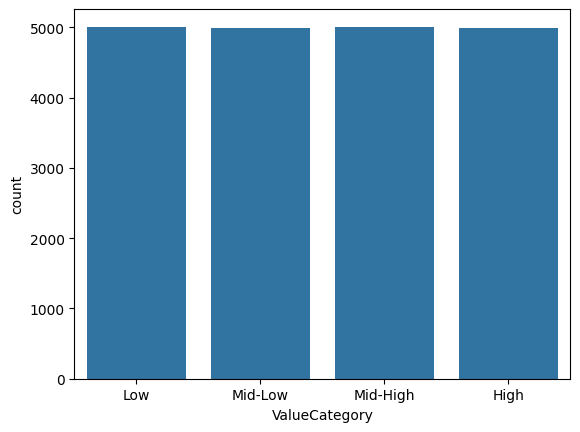

In [188]:
sns.countplot(data=df,x="ValueCategory")

In [189]:
X=df.drop(columns=["MedHouseVal","ValueCategory"])
print(X.shape,X.ndim)
Y=df.MedHouseVal
# print(df.MedHouseVal.isnull().sum())

print(Y)


(20000, 7) 2
0         540000
1         850909
2         880000
3         735000
4         577500
          ...   
19995    3648000
19996     466667
19997    1105000
19998     466364
19999    2091000
Name: MedHouseVal, Length: 20000, dtype: int64


In [190]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [191]:
model= LinearRegression()
model.fit(x_train,y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [192]:
print(model.intercept_)
print(model.coef_)

-1889382.7937554603
[-8.96175750e-01 -1.70048514e+05  5.27019111e+05  9.66058650e+05
 -1.14056466e+04  5.39201453e+04  5.21690378e+04]


In [193]:
y_pred=model.predict(x_test)

In [194]:
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print(f"mean squared error :{mse:.3f}")
print(f"r2 squared  :{r2:.3f}")

mean squared error :7426569272816.320
r2 squared  :0.359


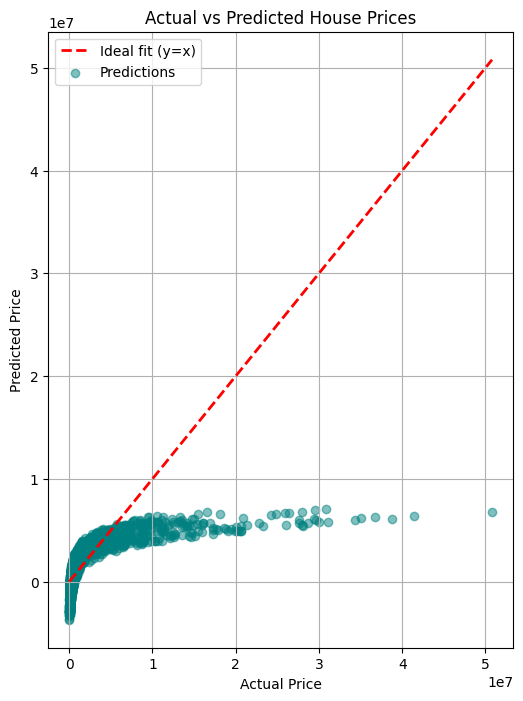

In [195]:
plt.figure(figsize=(6, 8))

# رسم خط y = x برای مقایسه‌ی پیش‌بینی با مقدار واقعی
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red", linestyle="--", linewidth=2, label="Ideal fit (y=x)")

# نقاط پیش‌بینی‌شده در مقابل واقعی
plt.scatter(y_test, y_pred, alpha=0.5, color="teal", label="Predictions")

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.legend()
plt.show()


In [196]:
for name, coef in zip(X, model.coef_):
    print(f"{name}: {coef:.3f}")

MedInc: -0.896
HouseAge: -170048.514
AveRooms: 527019.111
AveBedrms: 966058.650
AveOccup: -11405.647
Latitude: 53920.145
Longitude: 52169.038


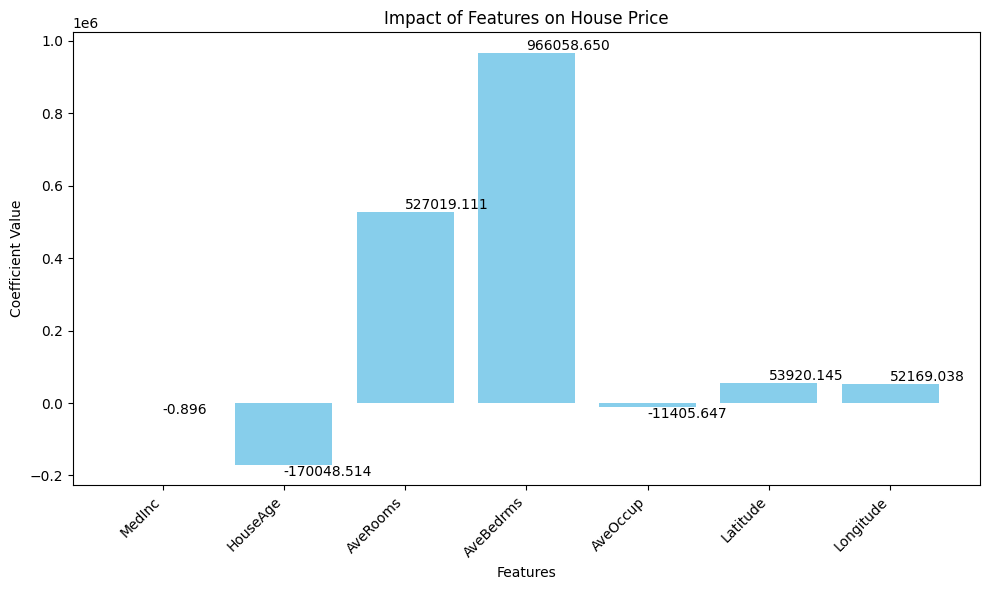

In [199]:
coefficients = model.coef_
# Create a figure and an axes object
fig, ax = plt.subplots(figsize=(10, 6))
# Create bar chart
bars = ax.bar(X.columns, coefficients, color='skyblue')

# Add labels and title
ax.set_xlabel("Features")
ax.set_ylabel("Coefficient Value")
ax.set_title("Impact of Features on House Price")

# Add coefficient values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval, f"{yval:.3f}", va='bottom' if yval >= 0 else 'top') # va: vertical alignment
    #get_x  vertical position
    #get_width half of horizental bar

# Improve layout
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Save the plot to a file
plt.savefig("./feature_impact_plot.png")

In [205]:
from sklearn.linear_model import Ridge,Lasso
ridge_model=Ridge(alpha=1.0)
ridge_model.fit(x_train,y_train)



,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [207]:
ridge_pred=ridge_model.predict(x_test)
mse_core_ridge=mean_squared_error(y_test,ridge_pred)
r2_core_ridge=r2_score(y_test,ridge_pred)
print(mse_core_ridge,r2_core_ridge)

7426579020517.934 0.358592090387745


In [209]:
from sklearn.linear_model import Ridge,Lasso
lasso_model=Lasso(alpha=1.0)
lasso_model.fit(x_train,y_train)

lasso_pred=lasso_model.predict(x_test)
mse_core_lasso=mean_squared_error(y_test,lasso_pred)
r2_core_lasso=r2_score(y_test,lasso_pred)
print(mse_core_lasso,r2_core_lasso)

7426569520879.204 0.3585929108386421


In [214]:
models={
    "linner":model,
    "ridge":ridge_model,
    "lasso":lasso_model
}
for name,m in models.items():
    print(f"\n {name} Coeffication:")
    for feature,coef in zip(X.columns,m.coef_):
        print(f"{feature}:  {coef}")


 linner Coeffication:
MedInc:  -0.8961757500549591
HouseAge:  -170048.5142077399
AveRooms:  527019.1114555454
AveBedrms:  966058.6503838537
AveOccup:  -11405.646594175592
Latitude:  53920.14528925766
Longitude:  52169.03782275939

 ridge Coeffication:
MedInc:  -0.8961761328709199
HouseAge:  -170048.51632556733
AveRooms:  527002.7031690174
AveBedrms:  965817.218412169
AveOccup:  -11405.942127626558
Latitude:  53920.16412403826
Longitude:  52169.03903755389

 lasso Coeffication:
MedInc:  -0.8961760164929775
HouseAge:  -170048.5029506753
AveRooms:  527018.6095311319
AveBedrms:  966054.662206017
AveOccup:  -11405.5323626184
Latitude:  53920.138141578966
Longitude:  52169.03041816734


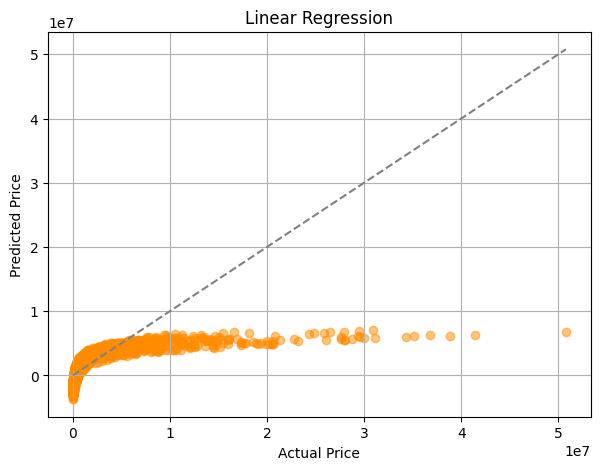

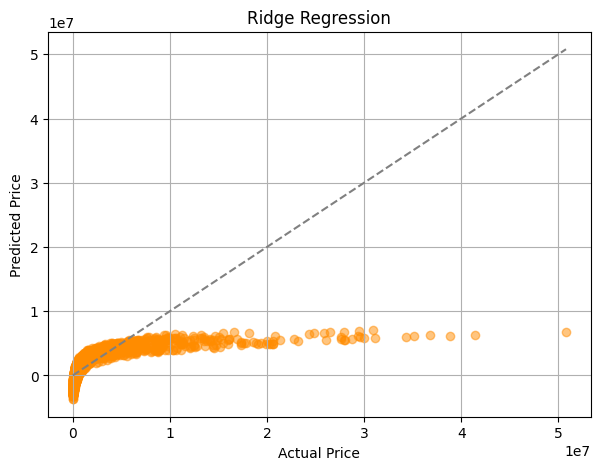

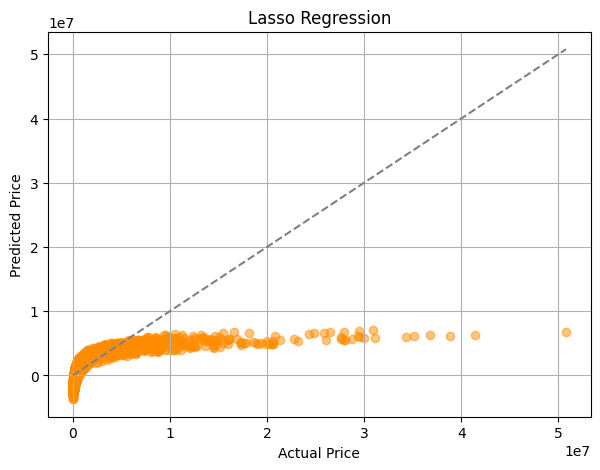

In [216]:
def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(7, 5))
    plt.scatter(y_true, y_pred, alpha=0.5, color='darkorange')
    plt.plot([y_true.min(), y_true.max()],
             [y_true.min(), y_true.max()],
             '--', color='gray')
    plt.xlabel("Actual Price")
    plt.ylabel("Predicted Price")
    plt.title(title)
    plt.grid(True)
    plt.show()

# Plot for each model
plot_predictions(y_test, model.predict(x_test), "Linear Regression")
plot_predictions(y_test, ridge_model.predict(x_test), "Ridge Regression")
plot_predictions(y_test, lasso_model.predict(x_test), "Lasso Regression")